<a href="https://colab.research.google.com/github/saaiiiifff/Database-Analytics/blob/main/02_sql_r_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%load_ext rpy2.ipython

In [6]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [7]:
import pandas as pd

deliveries = pd.read_csv('deliveries.csv')
complaints = pd.read_csv('complaints.csv')
customers = pd.read_csv('customers.csv')
drivers = pd.read_csv('drivers.csv')
hubs = pd.read_csv('hubs.csv')
orders = pd.read_csv('orders.csv')
vehicles = pd.read_csv('vehicles.csv')
incidents = pd.read_csv('incidents.csv')
app_events = pd.read_csv('app_events.csv')

print("All CSV files loaded successfully")

All CSV files loaded successfully


In [8]:
%%R
x <- 10
print(x)

[1] 10


In [9]:
%%R
install.packages("RSQLite")
install.packages("DBI")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_2.4.6.tar.gz'
Content type 'application/x-gzip' length 4356902 bytes (4.2 MB)
downloaded 4.2 MB


The downloaded source packages are in
	‘/tmp/RtmpWjfxj4/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/DBI_1.3.0.tar.gz'
Content type 'application/x-gzip' length 744704 bytes (727 KB)
downloaded 727 KB


The downloaded source packages are in
	‘/tmp/RtmpWjfxj4/downloaded_packages’


In [10]:
%%R
install.packages("DBI")
install.packages("RSQLite")
library(DBI)
library(RSQLite)

# create in-memory database
con <- dbConnect(RSQLite::SQLite(), ":memory:")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/DBI_1.3.0.tar.gz'
Content type 'application/x-gzip' length 744704 bytes (727 KB)
downloaded 727 KB


The downloaded source packages are in
	‘/tmp/RtmpWjfxj4/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_2.4.6.tar.gz'
Content type 'application/x-gzip' length 4356902 bytes (4.2 MB)
downloaded 4.2 MB


The downloaded source packages are in
	‘/tmp/RtmpWjfxj4/downloaded_packages’


In [11]:
%%R
install.packages("DBI")
install.packages("RSQLite")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/DBI_1.3.0.tar.gz'
Content type 'application/x-gzip' length 744704 bytes (727 KB)
downloaded 727 KB


The downloaded source packages are in
	‘/tmp/RtmpWjfxj4/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_2.4.6.tar.gz'
Content type 'application/x-gzip' length 4356902 bytes (4.2 MB)
downloaded 4.2 MB


The downloaded source packages are in
	‘/tmp/RtmpWjfxj4/downloaded_packages’


In [12]:
%%R
library(DBI)
library(RSQLite)

con <- dbConnect(RSQLite::SQLite(), ":memory:")
print("Connected successfully")

[1] "Connected successfully"


In [13]:
# Fix mixed ID columns by converting them to string
for df in [deliveries, complaints, customers, drivers, hubs, orders, vehicles, incidents, app_events]:
    for col in df.columns:
        if col.endswith("_id"):
            df[col] = df[col].astype(str)

print("ID columns converted to string")

ID columns converted to string


In [14]:
%R -i deliveries -i complaints -i customers -i drivers -i hubs -i orders -i vehicles -i incidents -i app_events

In [15]:
%%R
dbWriteTable(con, "deliveries", deliveries)
dbWriteTable(con, "complaints", complaints)
dbWriteTable(con, "customers", customers)
dbWriteTable(con, "drivers", drivers)
dbWriteTable(con, "hubs", hubs)
dbWriteTable(con, "orders", orders)
dbWriteTable(con, "vehicles", vehicles)
dbWriteTable(con, "incidents", incidents)
dbWriteTable(con, "app_events", app_events)

In [16]:
%%R
dbListTables(con)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"  


## SQL Query 1: Delivery Status Breakdown

This query counts how many deliveries were completed on time, delayed, or failed.

In [17]:
%%R
query1 <- "
SELECT
    delivery_status,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC;
"

result1 <- dbGetQuery(con, query1)
print(result1)

  delivery_status total_deliveries
1          OnTime              616
2         Delayed              202
3          Failed              132


## SQL Query 2: Delivery Status Percentage

This query calculates the percentage distribution of delivery outcomes.

In [18]:
%%R
query2 <- "
SELECT
    delivery_status,
    COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries) AS percentage
FROM deliveries
GROUP BY delivery_status
ORDER BY percentage DESC;
"

result2 <- dbGetQuery(con, query2)
print(result2)

  delivery_status percentage
1          OnTime   64.84211
2         Delayed   21.26316
3          Failed   13.89474


## SQL Query 3: Failed Deliveries by Hub

This query identifies which hubs have the highest number of failed deliveries.

In [19]:
%%R
query3 <- "
SELECT
    hub_id,
    COUNT(*) AS failed_deliveries
FROM deliveries
WHERE delivery_status = 'Failed'
GROUP BY hub_id
ORDER BY failed_deliveries DESC;
"

result3 <- dbGetQuery(con, query3)
print(result3)

  hub_id failed_deliveries
1    H08                26
2    H05                23
3    H01                17
4    H04                16
5    H06                15
6    H07                14
7    H03                11
8    H02                10


## SQL Query 4: Failure Rate by Hub

This query calculates the failure rate for each hub relative to total deliveries.

In [20]:
%%R
query4 <- "
SELECT
    hub_id,
    COUNT(CASE WHEN delivery_status = 'Failed' THEN 1 END) * 100.0 / COUNT(*) AS failure_rate
FROM deliveries
GROUP BY hub_id
ORDER BY failure_rate DESC;
"

result4 <- dbGetQuery(con, query4)
print(result4)

  hub_id failure_rate
1    H08    20.312500
2    H05    20.000000
3    H06    14.423077
4    H04    12.598425
5    H01    12.500000
6    H07    12.173913
7    H02     9.433962
8    H03     9.243697


## SQL Query 5: Failed Deliveries by Driver

This query identifies which drivers are responsible for the highest number of failed deliveries.

In [21]:
%%R
query5 <- "
SELECT
    driver_id,
    COUNT(*) AS failed_deliveries
FROM deliveries
WHERE delivery_status = 'Failed'
GROUP BY driver_id
ORDER BY failed_deliveries DESC
LIMIT 10;
"

result5 <- dbGetQuery(con, query5)
print(result5)

   driver_id failed_deliveries
1       D133                 4
2       D104                 4
3       D024                 4
4       D131                 3
5       D108                 3
6       D092                 3
7       D083                 3
8       D055                 3
9       D010                 3
10      D004                 3


## SQL Query 6: Failed Deliveries with Complaints

This query examines how many failed deliveries resulted in customer complaints.

In [22]:
%%R
query6 <- "
SELECT
    d.delivery_status,
    COUNT(c.complaint_id) AS complaint_count
FROM deliveries d
LEFT JOIN complaints c
ON d.order_id = c.order_id
WHERE d.delivery_status = 'Failed'
GROUP BY d.delivery_status;
"

result6 <- dbGetQuery(con, query6)
print(result6)

  delivery_status complaint_count
1          Failed              35


## SQL Query 7: Most Common Complaint Types

This query identifies the most frequent types of customer complaints.

In [23]:
%%R
query7 <- "
SELECT
    complaint_type,
    COUNT(*) AS total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC;
"

result7 <- dbGetQuery(con, query7)
print(result7)

     complaint_type total_complaints
1             Delay              101
2      MissedPickup               64
3          AppIssue               53
4   DriverBehaviour               51
5 SupportExperience               20
6           Billing               16
7            Damage               15


## SQL Query 8: Average Cost by Delivery Status

This query compares the average fuel or charge cost for different delivery outcomes.

In [24]:
%%R
query8 <- "
SELECT
    delivery_status,
    AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY delivery_status
ORDER BY avg_cost DESC;
"

result8 <- dbGetQuery(con, query8)
print(result8)

  delivery_status avg_cost
1          Failed 13.14795
2         Delayed 13.13871
3          OnTime 12.67805


In [25]:
%%R
dbExecute(con, "
INSERT INTO deliveries (delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status, fuel_or_charge_cost)
VALUES ('DL9999', 'O9999', 'D999', 'V999', 'H01', 'OnTime', 10.5);
")

[1] 1


In [26]:
%%R
dbExecute(con, "
UPDATE deliveries
SET delivery_status = 'Delayed'
WHERE delivery_id = 'DL9999';
")

[1] 1


In [27]:
%%R
dbExecute(con, "
DELETE FROM deliveries
WHERE delivery_id = 'DL9999';
")

[1] 1


In addition: Warning message:
call dbDisconnect() when finished working with a connection 


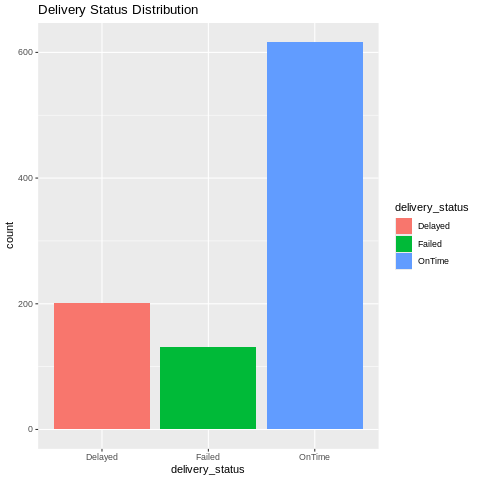

In [28]:
%%R
library(ggplot2)

data <- dbGetQuery(con, "
SELECT delivery_status, COUNT(*) as count
FROM deliveries
GROUP BY delivery_status
")

ggplot(data, aes(x=delivery_status, y=count, fill=delivery_status)) +
  geom_bar(stat="identity") +
  ggtitle("Delivery Status Distribution")